<a href="https://colab.research.google.com/github/aadithya-vimal/SamsungInnovationCampus/blob/main/practice_random_variables.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Practice Colab Notebook: Random Variables

This notebook is designed for **Computer Science and AI students** to practice the topic **Random Variables** using **NumPy, Matplotlib, and SciPy**.

## Learning goals
- Understand what a random variable is
- Distinguish between **discrete** and **continuous** random variables
- Compute **PMF**, **PDF**, and **CDF**
- Compute **expected value**, **variance**, and **standard deviation**
- Simulate real-world random processes
- Model simple AI/data-science scenarios using random variables


## Imports

We will use:
- `numpy` for arrays and simulation
- `matplotlib` for visualization
- `scipy.stats` for probability functions


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as st

%matplotlib inline
np.set_printoptions(precision=4, suppress=True)


## 1. Quick theory notes

A **random variable** maps the outcome of a random experiment to a number.

### Discrete random variable
A discrete random variable takes countable values such as:
- number of heads in 3 coin tosses
- number of emails received in an hour
- number of defective chips in a batch

We use a **probability mass function (PMF)**:
$$P(X=x)$$

### Continuous random variable
A continuous random variable takes values on an interval, such as:
- time taken by a server to respond
- height of students
- temperature of a machine

We use a **probability density function (PDF)**:
$$f(x)$$

For continuous variables, probability over an interval is computed using the **CDF**:
$$F(x)=P(X\le x)$$


## 2. Worked example: number of heads in 3 coin tosses

Let $X$ be the number of heads in 3 fair tosses.

Possible values are:
$$X \in \{0,1,2,3\}$$

This is a discrete random variable. It follows a binomial model with:
- $n=3$
- $p=0.5$


In [ ]:
# PMF of X = number of heads in 3 fair tosses
n = 3
p = 0.5
x = np.arange(0, n+1)
pmf = st.binom.pmf(x, n, p)

print("x values:", x)
print("PMF values:", pmf)
print("Total probability:", pmf.sum())


x values: [0 1 2 3]
PMF values: [0.125 0.375 0.375 0.125]
Total probability: 1.0000000000000002


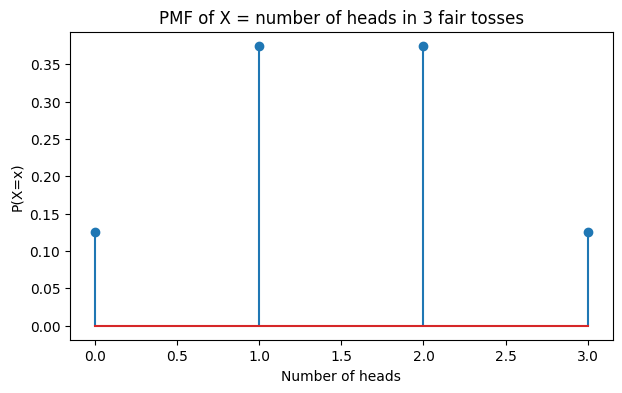

In [ ]:
# Visualize the PMF
plt.figure(figsize=(7,4))
plt.stem(x, pmf)
plt.xlabel("Number of heads")
plt.ylabel("P(X=x)")
plt.title("PMF of X = number of heads in 3 fair tosses")
plt.show()


CDF values: [0.125 0.5   0.875 1.   ]


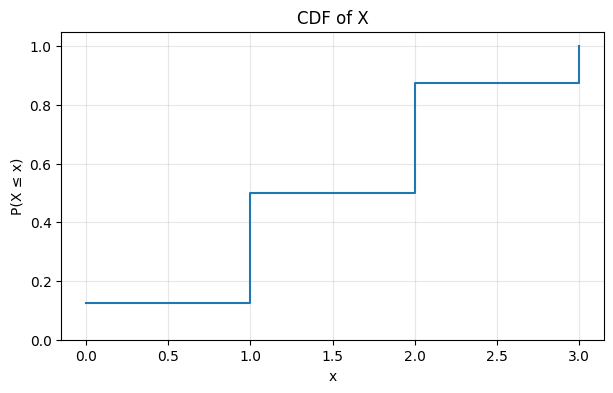

In [ ]:
# CDF of the same random variable
cdf = st.binom.cdf(x, n, p)
print("CDF values:", cdf)

plt.figure(figsize=(7,4))
plt.step(x, cdf, where='post')
plt.xlabel("x")
plt.ylabel("P(X ≤ x)")
plt.title("CDF of X")
plt.ylim(0, 1.05)
plt.grid(True, alpha=0.3)
plt.show()


In [ ]:
# Expected value and variance
mean_x = st.binom.mean(n, p)
var_x = st.binom.var(n, p)
std_x = st.binom.std(n, p)

print("Mean:", mean_x)
print("Variance:", var_x)
print("Standard deviation:", std_x)


Mean: 1.5
Variance: 0.75
Standard deviation: 0.8660254037844386


## 3. Simulation view of a random variable

We now simulate the experiment many times and compare the empirical frequencies with the theoretical PMF.


In [ ]:
# Simulate 10,000 repetitions
samples = st.binom.rvs(n=3, p=0.5, size=10000, random_state=42)

empirical_pmf = np.array([(samples == k).mean() for k in x])
theoretical_pmf = st.binom.pmf(x, 3, 0.5)

print("Empirical PMF:", empirical_pmf)
print("Theoretical PMF:", theoretical_pmf)


Empirical PMF: [0.1278 0.3798 0.3728 0.1196]
Theoretical PMF: [0.125 0.375 0.375 0.125]


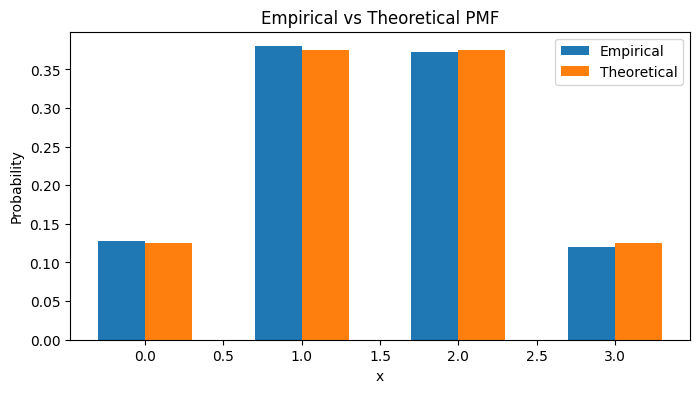

In [ ]:
# Compare empirical and theoretical PMF
plt.figure(figsize=(8,4))
plt.bar(x - 0.15, empirical_pmf, width=0.3, label="Empirical")
plt.bar(x + 0.15, theoretical_pmf, width=0.3, label="Theoretical")
plt.xlabel("x")
plt.ylabel("Probability")
plt.title("Empirical vs Theoretical PMF")
plt.legend()
plt.show()


## 4. Continuous random variable example: waiting time for a bus

Assume the waiting time $X$ for a shuttle bus is uniformly distributed between 0 and 10 minutes.

Then:
$$X \sim U(0,10)$$

This is a continuous random variable.


In [ ]:
# Uniform random variable for waiting time
a = 0
b = 10
scale = b - a

x_cont = np.linspace(-1, 11, 400)
pdf_vals = st.uniform.pdf(x_cont, loc=a, scale=scale)
cdf_vals = st.uniform.cdf(x_cont, loc=a, scale=scale)

print("P(2 ≤ X ≤ 6) =", st.uniform.cdf(6, loc=a, scale=scale) - st.uniform.cdf(2, loc=a, scale=scale))
print("Mean =", st.uniform.mean(loc=a, scale=scale))
print("Variance =", st.uniform.var(loc=a, scale=scale))


P(2 ≤ X ≤ 6) = 0.39999999999999997
Mean = 5.0
Variance = 8.333333333333332


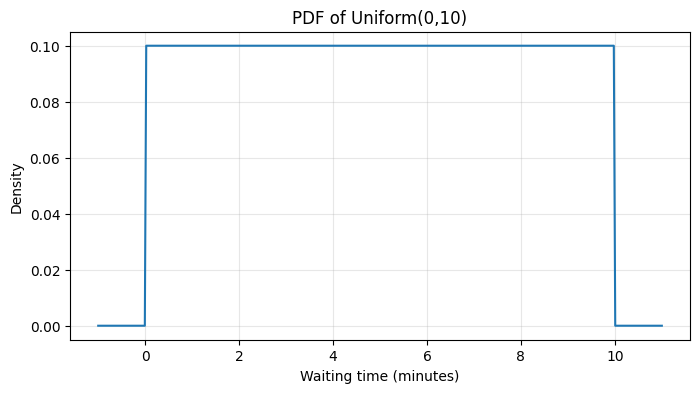

In [ ]:
# Plot PDF
plt.figure(figsize=(8,4))
plt.plot(x_cont, pdf_vals)
plt.xlabel("Waiting time (minutes)")
plt.ylabel("Density")
plt.title("PDF of Uniform(0,10)")
plt.grid(True, alpha=0.3)
plt.show()


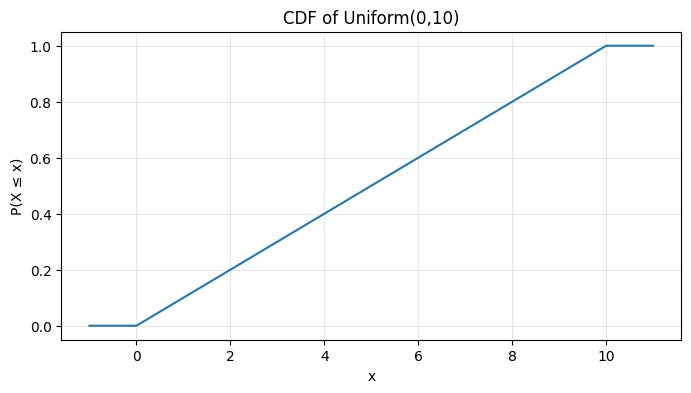

In [ ]:
# Plot CDF
plt.figure(figsize=(8,4))
plt.plot(x_cont, cdf_vals)
plt.xlabel("x")
plt.ylabel("P(X ≤ x)")
plt.title("CDF of Uniform(0,10)")
plt.grid(True, alpha=0.3)
plt.show()




```

```

## Normal Distribution for Waiting Time

While a uniform distribution is simple, sometimes a **Normal (Gaussian) distribution** might be a more realistic model for waiting times if there's a most common waiting time and deviations from it are less frequent.

Let's assume the waiting time $X$ for a shuttle bus follows a Normal distribution with a mean ($\mu$) of 5 minutes and a standard deviation ($\sigma$) of 1.5 minutes.

Then:
$$X \sim N(5, 1.5^2)$$

This is a continuous random variable.

In [ ]:
mu_normal = 5
sigma_normal = 1.5

x_normal = np.linspace(0, 10, 400)
pdf_normal_vals = st.norm.pdf(x_normal, loc=mu_normal, scale=sigma_normal)
cdf_normal_vals = st.norm.cdf(x_normal, loc=mu_normal, scale=sigma_normal)

print(f"P(X <= 6) = {st.norm.cdf(6, loc=mu_normal, scale=sigma_normal):.4f}")
print(f"P(2 <= X <= 8) = {st.norm.cdf(8, loc=mu_normal, scale=sigma_normal) - st.norm.cdf(2, loc=mu_normal, scale=sigma_normal):.4f}")
print(f"Mean (Normal) = {st.norm.mean(loc=mu_normal, scale=sigma_normal)}")
print(f"Variance (Normal) = {st.norm.var(loc=mu_normal, scale=sigma_normal)}")

P(X <= 6) = 0.7475
P(2 <= X <= 8) = 0.9545
Mean (Normal) = 5.0
Variance (Normal) = 2.25


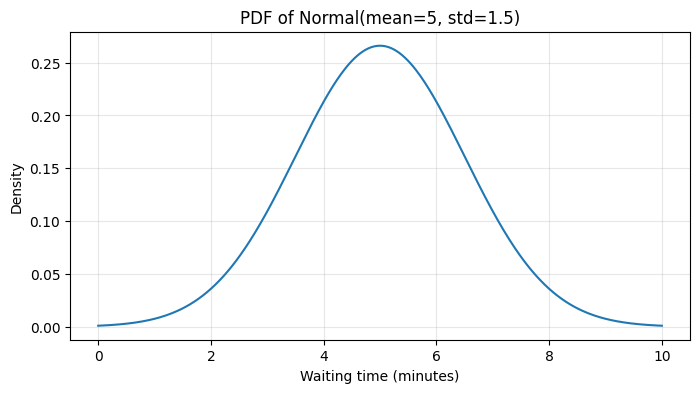

In [ ]:
# Plot PDF for Normal Distribution
plt.figure(figsize=(8,4))
plt.plot(x_normal, pdf_normal_vals)
plt.xlabel("Waiting time (minutes)")
plt.ylabel("Density")
plt.title("PDF of Normal(mean=5, std=1.5)")
plt.grid(True, alpha=0.3)
plt.show()

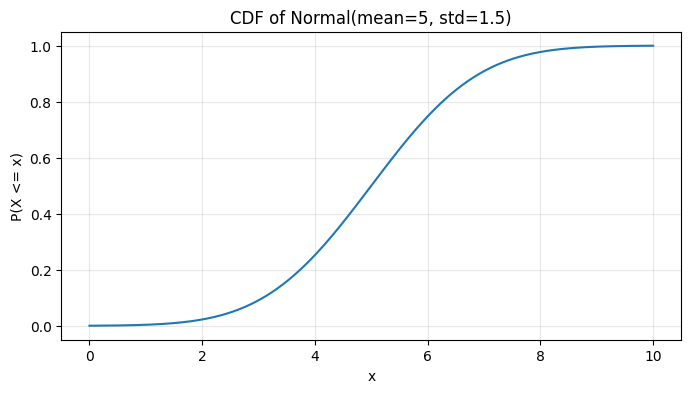

In [ ]:
# Plot CDF for Normal Distribution
plt.figure(figsize=(8,4))
plt.plot(x_normal, cdf_normal_vals)
plt.xlabel("x")
plt.ylabel("P(X <= x)")
plt.title("CDF of Normal(mean=5, std=1.5)")
plt.grid(True, alpha=0.3)
plt.show()

## 5. Real-world modeling examples

### Example A: Number of login failures
Let $X$ be the number of failed login attempts in one minute.

This is naturally a **discrete random variable**.

### Example B: Model inference time
Let $T$ be the response time of an AI model in seconds.

This is naturally a **continuous random variable**.

### Example C: Sensor noise
Let $N$ be the measurement error from a temperature sensor.

This is often modeled as a **continuous random variable**, frequently normal.


## 6. Practice exercises

### Exercise 1: Random variable from dice
Let $X$ be the number shown on a fair die.
1. Write the support of $X$.
2. Build the PMF manually using NumPy.
3. Verify that total probability is 1.
4. Compute the mean and variance manually.
5. Plot the PMF.

### Exercise 2: Indicator random variable
Let $X=1$ if a tossed coin shows Head, and $X=0$ otherwise.
1. Write its PMF.
2. Compute $E[X]$.
3. Compute $Var(X)$.
4. Simulate 5000 tosses and compare empirical mean with theoretical mean.

### Exercise 3: Continuous waiting-time model
Let $X \sim U(5,15)$.
1. Plot the PDF.
2. Plot the CDF.
3. Compute $P(X \le 8)$.
4. Compute $P(9 \le X \le 12)$.
5. Compute the mean and variance.

### Exercise 4: AI inference time
Assume the time taken by a chatbot to answer a query follows a normal random variable with mean 2.5 seconds and standard deviation 0.4 seconds.
1. Plot the PDF.
2. Compute $P(T \le 3)$.
3. Compute $P(2 \le T \le 3)$.
4. Generate 1000 samples and visualize a histogram.

### Exercise 5: Student challenge
Create your own random variable from a real-life AI or CS problem and answer:
1. Is it discrete or continuous?
2. What values can it take?
3. Which distribution may be appropriate?
4. How would PMF/PDF and CDF help in decision-making?


In [ ]:
# -----------------------------
# Exercise 1 starter
# Fair die random variable
# -----------------------------
x = np.arange(1, 7)
pmf = np.ones(6) / 6

print("Support:", x)
print("PMF:", pmf)
print("Total probability:", pmf.sum())

# TODO:
# 1. Compute the mean manually
# 2. Compute the variance manually
# 3. Plot the PMF


In [ ]:
# -----------------------------
# Exercise 2 starter
# Indicator random variable
# -----------------------------
x = np.array([0, 1])
pmf = np.array([0.5, 0.5])

# TODO:
# 1. Compute E[X]
# 2. Compute Var(X)
# 3. Simulate 5000 tosses
# 4. Compare empirical and theoretical mean


In [ ]:
# -----------------------------
# Exercise 3 starter
# Uniform random variable U(5,15)
# -----------------------------
a = 5
b = 15
scale = b - a

# TODO:
# 1. Create x values using np.linspace
# 2. Plot PDF using st.uniform.pdf
# 3. Plot CDF using st.uniform.cdf
# 4. Compute interval probabilities


In [ ]:
# -----------------------------
# Exercise 4 starter
# Normal random variable for inference time
# -----------------------------
mu = 2.5
sigma = 0.4

# TODO:
# 1. Create x values
# 2. Plot PDF using st.norm.pdf
# 3. Compute P(T <= 3)
# 4. Compute P(2 <= T <= 3)
# 5. Simulate 1000 samples and plot histogram


## 7. Reflection questions

1. Why is a PMF used for discrete variables but a PDF used for continuous variables?
2. Why is $P(X=x)=0$ possible for a continuous random variable?
3. In AI systems, which variables are better modeled as discrete and which as continuous?
4. How does simulation help us understand a random variable?
